# 📊 Stage 1 — Descriptive Statistics
## E-Commerce Customer Spend Analysis
### Complete Step-by-Step Jupyter Notebook

---

> **Goal:** Understand what your data looks like — its center, spread, shape, and outliers — before making any business decisions.

> 📌 **Tamil:** "உங்கள் data-ஐ describe பண்ண சொல்லும் statistics — average, spread, shape. Data பத்தி முதல்ல புரிஞ்சுக்கணும்."

---

### 🗂️ What We Will Cover
| Step | Topic | Concept |
|------|-------|---------|
| 1 | Dataset Overview | Shape, dtypes, missing values |
| 2 | Central Tendency | Mean, Median, Mode |
| 3 | Spread / Dispersion | Std Dev, Variance, IQR |
| 4 | Shape | Skewness, Kurtosis |
| 5 | Outlier Detection | IQR Fence Method |
| 6 | Percentile Analysis | P25, P50, P75, P90, P99 |
| 7 | Category Breakdown | Group-wise statistics |
| 8 | Normality Test | Shapiro-Wilk |
| 9 | Visualizations | 6-Panel Dashboard |
| 10 | Business Recommendations | Actionable insights |

---

## ⚙️ Step 0 — Install Libraries & Import Packages

Run this cell first to make sure all required libraries are available.

In [2]:
# Install if needed (uncomment and run once)
# !pip install pandas numpy scipy matplotlib seaborn

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Global Color Palette ──────────────────────────
PURPLE = '#534AB7'
TEAL   = '#0F6E56'
AMBER  = '#BA7517'
CORAL  = '#993C1D'
BLUE   = '#185FA5'
LGRAY  = '#F1EFE8'
DGRAY  = '#5F5E5A'

# ── Plot Style ────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FFFFFF',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

print("✅ All libraries imported successfully!")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")

✅ All libraries imported successfully!
  pandas  : 3.0.3
  numpy   : 2.4.4


---
## 🗄️ Step 0b — Generate the Dataset

We create a **realistic synthetic e-commerce dataset** with 1,000 Indian customers.

> 📌 **Tamil:** "Real data போல் synthetic dataset create பண்றோம் — Indian e-commerce context."

**Dataset columns:**
- `customer_id` — Unique customer ID
- `city` — Indian city
- `age_group` — Customer age bracket
- `category` — Product category
- `order_value_inr` — Order value in Indian Rupees ₹ (our main variable)
- `num_items` — Number of items in order
- `recency_days` — Days since last order
- `rating` — Customer rating (1–5)
- `discount_pct` — Discount applied (%)

In [3]:
np.random.seed(42)
n = 1000

customer_ids = [f"CUST_{i:04d}" for i in range(1, n+1)]

cities = np.random.choice(
    ['Chennai', 'Mumbai', 'Delhi', 'Bangalore', 'Hyderabad', 'Pune', 'Kolkata'],
    n, p=[0.20, 0.18, 0.17, 0.15, 0.13, 0.10, 0.07]
)

categories = np.random.choice(
    ['Electronics', 'Fashion', 'Groceries', 'Books', 'Home Decor', 'Sports'],
    n, p=[0.25, 0.22, 0.18, 0.12, 0.13, 0.10]
)

# Right-skewed order values (realistic — most orders small, few very large)
base_order = np.random.lognormal(mean=4.5, sigma=0.8, size=n)
cat_mult   = {'Electronics': 3.5, 'Fashion': 1.2, 'Groceries': 0.6,
              'Books': 0.5, 'Home Decor': 1.8, 'Sports': 1.4}
order_values = np.array([base_order[i] * cat_mult[categories[i]] for i in range(n)])
order_values = np.clip(order_values, 50, 50000).round(2)

# Add VIP outliers (2% big spenders)
outlier_idx = np.random.choice(n, size=20, replace=False)
order_values[outlier_idx] = np.random.uniform(15000, 50000, 20).round(2)

ages         = np.random.choice(['18-25','26-35','36-45','46-55','55+'],
                                 n, p=[0.22, 0.35, 0.25, 0.12, 0.06])
num_items    = np.random.randint(1, 12, n)
recency_days = np.random.exponential(scale=45, size=n).astype(int).clip(1, 365)
ratings      = np.random.choice([1,2,3,4,5], n, p=[0.04, 0.07, 0.16, 0.40, 0.33])
discount_pct = np.random.choice([0,5,10,15,20,25,30], n,
                                 p=[0.30,0.15,0.20,0.15,0.10,0.06,0.04])

df = pd.DataFrame({
    'customer_id':     customer_ids,
    'city':            cities,
    'age_group':       ages,
    'category':        categories,
    'order_value_inr': order_values,
    'num_items':       num_items,
    'recency_days':    recency_days,
    'rating':          ratings,
    'discount_pct':    discount_pct
})

# df.to_csv('ecommerce_orders.csv', index=False)

# OR load from the provided CSV:
df = pd.read_csv('ecommerce_orders.csv')
print(f"✅ Dataset created: {len(df):,} rows × {df.shape[1]} columns")
df.head(10)

✅ Dataset created: 1,000 rows × 9 columns


,customer_id,city,age_group,category,order_value_inr,num_items,recency_days,rating,discount_pct
0,CUST_0001,Mumbai,18-25,Electronics,156.08,7,8,3,30
1,CUST_0002,Kolkata,36-45,Groceries,50.00,1,56,4,0
2,CUST_0003,Hyderabad,18-25,Home Decor,135.18,10,8,4,0
3,CUST_0004,Bangalore,36-45,Books,60.39,9,12,4,25
4,CUST_0005,Chennai,26-35,Home Decor,336.52,4,30,3,10
5,CUST_0006,Chennai,18-25,Books,50.00,3,110,5,10
6,CUST_0007,Chennai,36-45,Books,148.56,4,10,4,10
7,CUST_0008,Pune,26-35,Home Decor,130.44,4,7,5,0
8,CUST_0009,Bangalore,55+,Electronics,309.72,10,64,1,15
9,CUST_0010,Hyderabad,26-35,Groceries,50.00,11,31,4,15


---
## 📋 Step 1 — Dataset Overview

> 📌 **Tamil:** "Dataset-ஐ முதல்ல explore பண்ணுவது — shape, column types, missing values பாக்கணும்."

Always start every project by understanding the structure of your data.
- **Shape** — how many rows and columns?
- **dtypes** — which columns are numeric vs categorical?
- **Missing values** — any gaps in data?

In [4]:
ov = df['order_value_inr']   # Our main column of interest

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
# shape
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print()

# Data types
print("── Column Data Types ──")
print(df.dtypes.to_string())
print()

# Missing values
missing = df.isnull().sum()
print("── Missing Values ──")
print(missing[missing > 0] if missing.sum() > 0 else "  ✅ No missing values found!")
print()

# Value counts for categorical columns
print("── Category Distribution ──")
print(df['category'].value_counts())

  DATASET OVERVIEW
  Rows    : 1,000
  Columns : 9

── Column Data Types ──
customer_id            str
city                   str
age_group              str
category               str
order_value_inr    float64
num_items            int64
recency_days         int64
rating               int64
discount_pct         int64

── Missing Values ──
  ✅ No missing values found!

── Category Distribution ──
category
Electronics    258
Fashion        193
Groceries      179
Home Decor     140
Books          133
Sports          97
Name: count, dtype: int64


In [5]:
# Quick statistical summary of ALL numeric columns
print("── Numeric Summary (pandas .describe()) ──")
df.describe().round(2)

── Numeric Summary (pandas .describe()) ──


,order_value_inr,num_items,recency_days,rating,discount_pct
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,781.41,6.03,44.40,3.88,9.18
std,4282.41,3.11,45.42,1.03,8.68
min,50.00,1.00,1.00,1.00,0.00
25%,58.77,3.00,12.00,3.00,0.00
50%,124.05,6.00,30.00,4.00,10.00
75%,262.34,9.00,63.00,5.00,15.00
max,49114.17,11.00,338.00,5.00,30.00


---
## 📐 Step 2 — Measures of Central Tendency

> 📌 **Tamil:** "Data-இன் center எங்கே இருக்கிறது என்று கண்டுபிடிக்கும் measures — Mean, Median, Mode."

| Measure | Definition | Best Used When |
|---------|-----------|---------------|
| **Mean** | Sum ÷ Count | Data is symmetric, no outliers |
| **Median** | Middle value when sorted | Data is skewed (income, order values) |
| **Mode** | Most frequently occurring value | Categorical data, most common item |

### ⚠️ Key Insight
When **Mean > Median**, your data is **right-skewed** — a few large values pull the mean up.  
Always use **Median** for business KPIs involving money/income.

In [6]:
# ✅ Mean > Median: ➜ Right Skewed (Positive Skew)
# ✅ Median > Mean : ➜ Left Skewed (Negative Skew)

# ✅ Mean > Median → Right Skewed: 100, 120, 130, 150, 5000
# 👉 சில பெரிய பெரிய values இருக்கிறது
# 👉 அந்த பெரிய values mean-ஐ மேலே இழுக்கிறது
# 👉 அதனால் graph வலது பக்கம் நீளமாக இருக்கும்

# ✅ Median > Mean → Left Skewed:
# 👉 சில மிகவும் குறைந்த values இருக்கிறது
# 👉 அந்த small values mean-ஐ கீழே இழுக்கிறது
# 👉 graph இடது பக்கம் நீளமாக இருக்கும்

mean_val   = ov.mean()
median_val = ov.median()
mode_val   = ov.mode()[0]

print("── Measures of Central Tendency ──")
print(f"  Mean   (average)  : ₹{mean_val:>10,.2f}")
print(f"  Median (middle)   : ₹{median_val:>10,.2f}")
print(f"  Mode   (most freq): ₹{mode_val:>10,.2f}")
print()

# 👉 Mean median-ஐ விட எவ்வளவு percentage அதிகம் என்பதை கணக்கிடுகிறது.
diff_pct = ((mean_val - median_val) / median_val) * 100
print(f"  ► Mean is {diff_pct:.1f}% HIGHER than Median")
print()
print("  Why does this matter?")
print("  ─────────────────────────────────────────────")
print("  If a manager says 'our average order is ₹781'")
print("  they're being MISLED by big spenders.")
print("  The REAL typical customer spends only ₹124!")
print("  → Always report MEDIAN for skewed financial data.")

── Measures of Central Tendency ──
  Mean   (average)  : ₹    781.41
  Median (middle)   : ₹    124.05
  Mode   (most freq): ₹     50.00

  ► Mean is 529.9% HIGHER than Median

  Why does this matter?
  ─────────────────────────────────────────────
  If a manager says 'our average order is ₹781'
  they're being MISLED by big spenders.
  The REAL typical customer spends only ₹124!
  → Always report MEDIAN for skewed financial data.


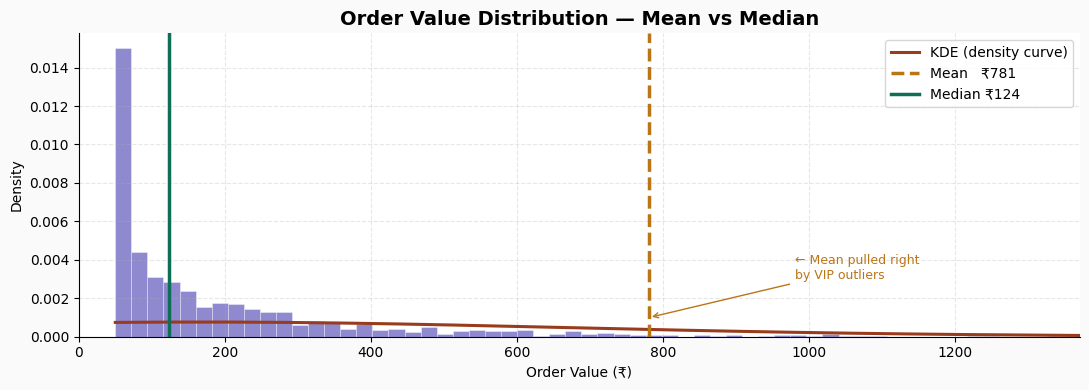

In [7]:
# Visual: Mean vs Median comparison - Order values எப்படி distribution ஆக இருக்கிறது? Mean மற்றும் Median எவ்வளவு வேறுபடுகிறது?
fig, ax = plt.subplots(figsize=(11, 4))

ax.hist(ov[ov < ov.quantile(0.97)], bins=60, color=PURPLE, # மிகப்பெரிய extreme outliers remove செய்கிறது.சில huge VIP orders graph-ஐ spoil செய்யலாம் visualization clear ஆக இருக்க வேண்டும்
        alpha=0.65, edgecolor='white', linewidth=0.4, density=True)

# KDE curve - (Kernel Density Estimation) curve உருவாக்குகிறது
ov_kde = ov[ov < ov.quantile(0.99)]
kde_x  = np.linspace(ov_kde.min(), ov_kde.max(), 300)
kde    = stats.gaussian_kde(ov_kde)
ax.plot(kde_x, kde(kde_x), color=CORAL, linewidth=2.2, label='KDE (density curve)')

ax.axvline(mean_val,   color=AMBER, linewidth=2.5, linestyle='--',
           label=f'Mean   ₹{mean_val:,.0f}')
ax.axvline(median_val, color=TEAL,  linewidth=2.5, linestyle='-',
           label=f'Median ₹{median_val:,.0f}')

ax.set_title('Order Value Distribution — Mean vs Median', fontsize=14, fontweight='bold')
ax.set_xlabel('Order Value (₹)'); ax.set_ylabel('Density')
ax.legend(fontsize=10)
ax.set_xlim(0, ov.quantile(0.97))

ax.annotate('← Mean pulled right\nby VIP outliers',
            xy=(mean_val, 0.0010), xytext=(mean_val+200, 0.0030),
            arrowprops=dict(arrowstyle='->', color=AMBER), color=AMBER, fontsize=9)

plt.tight_layout()
plt.show()

---
## 📏 Step 3 — Measures of Spread (Dispersion)

> 📌 **Tamil:** "Data எவ்வளவு spread ஆகி இருக்கிறது என்று measure பண்றோம் — Std Dev, IQR."

Spread tells you how **consistent** or **variable** your customers are.

| Measure | Definition |
|---------|-----------|
| **Variance** | Average squared distance from the mean |
| **Std Deviation** | Square root of variance (same unit as data) |
| **IQR** | Q3 − Q1 — middle 50% of data spread |
| **CV (Coeff. of Variation)** | Std Dev ÷ Mean × 100% — relative spread |

In [8]:
# [100, 105, 110, 95, 102] - 👉 First shop = consistent customers
# [50, 100, 500, 20, 900] - 👉 Second shop = unpredictable customers
# இதைத்தான் spread measures கண்டுபிடிக்கும்.

# variance = ஒவ்வொரு value-மும் mean-இலிருந்து எவ்வளவு distance என்று பார்க்கிறோம்.
# ஆனா negative வரக்கூடாது என்பதால்: 👉 distance-ஐ square செய்கிறோம். அதன் average = Variance.

# std: Variance கொஞ்சம் பெரிய squared number ஆக இருக்கும்.
# அதை normal unit-க்கு கொண்டு வர: 👉 square root எடுத்தால் Std Deviation. 

# Range=Max−Min - Largest value − smallest value.

# Quartiles: Quartiles data-வை 4 equal parts-ஆ split செய்கிறது.
# Quartile	Meaning
# Q1	    25% point - data இதற்குக் கீழே இருக்கும்.
# Q2	    Median , data கீழே இருக்கும்.
# Q3	    75% point , data கீழே இருக்கும்.
# IQR=Q3−Q1: Middle 50% data எவ்வளவு spread ஆகி இருக்கிறது?
# Outliers இருந்தாலும் IQR stable. அதனால் boxplot-ல் அதிகம் use பண்ணுவாங்க.

# Coefficient of Variation (CV) = (std_dev / mean) * 100
# Spread-ஐ relative percentage-ஆ measure செய்கிறது. CV அதிகம் என்றால் data values mean-ஐ விட எவ்வளவு அதிகமாக spread ஆகி இருக்கிறது என்று காட்டுகிறது.
# CV = 0% → No variability (all values are the same)
# CV < 20% → Low variability
# CV 20-50% → Moderate variability
# CV > 50% → High variability

std_val   = ov.std()
var_val   = ov.var()
range_val = ov.max() - ov.min()
cv        = (std_val / mean_val) * 100
q1, q2, q3 = ov.quantile([0.25, 0.50, 0.75])
iqr         = q3 - q1

print("── Measures of Spread ──")
print(f"  Variance              : ₹{var_val:>15,.2f}")
print(f"  Standard Deviation    : ₹{std_val:>15,.2f}")
print(f"  Range (Max - Min)     : ₹{range_val:>15,.2f}")
print(f"  Coeff. of Variation   : {cv:>14.1f}%  ← very high = huge spread")
print()
print("── Quartiles ──")
print(f"  Q1  (25th percentile) : ₹{q1:>10,.2f}  — 25% of orders below this")
print(f"  Q2  (50th = Median)   : ₹{q2:>10,.2f}  — half of orders below this")
print(f"  Q3  (75th percentile) : ₹{q3:>10,.2f}  — 75% of orders below this")
print(f"  IQR (Q3 - Q1)         : ₹{iqr:>10,.2f}  — middle 50% range")
print()
print(f"  ► CV = {cv:.0f}% means orders vary wildly.")
print(f"    A CV > 100% means std dev > mean — high variability!")

# ✅ Majority customers small orders place செய்கிறார்கள்
# ✅ Normal orders ₹58–₹262 range-ல் இருக்கிறது
# ✅ But few customers extremely huge orders place செய்கிறார்கள்
# ✅ அதனால் Std Dev & CV massive ஆகி இருக்கிறது
# ✅ Data highly skewed / inconsistent

── Measures of Spread ──
  Variance              : ₹  18,338,995.62
  Standard Deviation    : ₹       4,282.41
  Range (Max - Min)     : ₹      49,064.17
  Coeff. of Variation   :          548.0%  ← very high = huge spread

── Quartiles ──
  Q1  (25th percentile) : ₹     58.77  — 25% of orders below this
  Q2  (50th = Median)   : ₹    124.05  — half of orders below this
  Q3  (75th percentile) : ₹    262.34  — 75% of orders below this
  IQR (Q3 - Q1)         : ₹    203.57  — middle 50% range

  ► CV = 548% means orders vary wildly.
    A CV > 100% means std dev > mean — high variability!


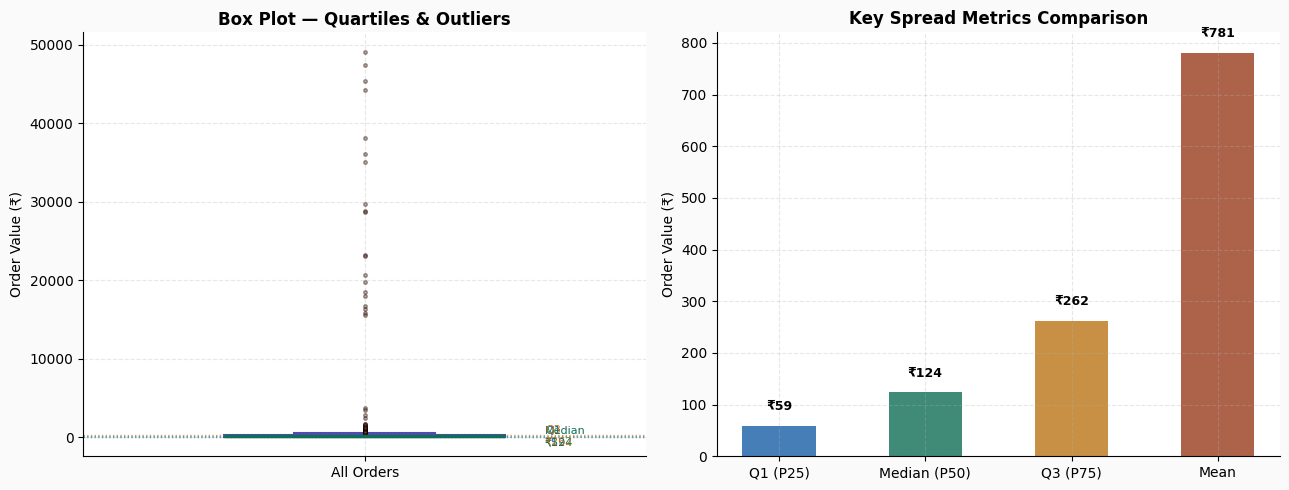

In [9]:
# Chart	        Purpose
# Box Plot	    Quartiles + Outliers பார்க்க
# Bar Chart	    Q1, Median, Q3, Mean compare செய்ய

# Visual: Box plot — see quartiles and outliers clearly
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot - Box Plot என்றால் என்ன? Data எப்படி spread ஆகி இருக்கிறது என்பதை quick-ஆ காட்டும் chart. இதில்: Median, Quartiles, IQR, Outliers அனைத்தும் ஒரே chart-ல் தெரியும்.
bp = axes[0].boxplot(
    ov, patch_artist=True, vert=True, widths=0.5,
    boxprops=dict(facecolor=LGRAY, color=PURPLE, linewidth=1.5),
    whiskerprops=dict(color=PURPLE, linewidth=1.5),
    capprops=dict(color=PURPLE, linewidth=1.5),
    flierprops=dict(marker='.', markerfacecolor=CORAL, alpha=0.4, markersize=5),
    medianprops=dict(color=TEAL, linewidth=2.5)
)

# Annotate quartile lines
for val, label, col in [(q1,'Q1',BLUE),(q2,'Median',TEAL),(q3,'Q3',AMBER)]:
    axes[0].axhline(val, color=col, linestyle=':', linewidth=1, alpha=0.6)
    axes[0].text(1.32, val, f'{label}\n₹{val:,.0f}', va='center', fontsize=8, color=col)

axes[0].set_title('Box Plot — Quartiles & Outliers', fontweight='bold')
axes[0].set_ylabel('Order Value (₹)')
axes[0].set_xticklabels(['All Orders'])

# Bar chart: Q1, Median, Q3, Mean
labels  = ['Q1 (P25)', 'Median (P50)', 'Q3 (P75)', 'Mean']
values  = [q1, median_val, q3, mean_val]
colors  = [BLUE, TEAL, AMBER, CORAL]
bars    = axes[1].bar(labels, values, color=colors, alpha=0.8, width=0.5)
for bar, v in zip(bars, values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'₹{v:,.0f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Key Spread Metrics Comparison', fontweight='bold')
axes[1].set_ylabel('Order Value (₹)')

plt.tight_layout()
plt.show()

# Situation	        Meaning
# Mean ≈ Median	    Symmetric data
# Mean > Median	    Right skew
# Mean < Median	    Left skew

---
## 🔔 Step 4 — Shape: Skewness & Kurtosis

> 📌 **Tamil:** "Distribution-இன் shape எப்படி இருக்கிறது — right-skewed, left-skewed, or symmetric."

### Skewness
| Value | Meaning |
|-------|---------|
| `0` | Perfectly symmetric (normal distribution) |
| `> 0.5` | Right-skewed (long tail to right — income, order values) Positive|
| `< -0.5` | Left-skewed (long tail to left) Negative |

### Kurtosis
| Value | Meaning |
|-------|---------|
| `~0` | Normal tails (mesokurtic) |
| `> 0` | Heavy tails — extreme values more common (leptokurtic) |
| `< 0` | Light tails — fewer extremes (platykurtic) |

In [10]:
# Skewness - Data எந்த side-க்கு அதிகமாக tail (நீளம்) இருக்கிறது
# Right skew is positive meaning most values small few values large
# Left skew is negative meaning most values large few values small
# symmetric both sides equal

# Kurtosis -Extreme values (outliers) எவ்வளவு அதிகம் இருக்கிறது?
# High kurtosis tall peak heavy tail extreme values (outliers) அதிகம் இருக்கிறது
# Low kurtosis flat peak light tail extreme values (outliers) குறைவாக இருக்கிறது

# Kurtosis	Meaning
# 0	        Normal
# 1–3	    Moderate heavy tails
# >3	    Heavy tails

skew_val = ov.skew()
kurt_val = ov.kurtosis()  # Excess kurtosis (normal = 0)

print("── Shape of Distribution ──")
print(f"  Skewness  : {skew_val:.4f}")
if skew_val > 1: #Skewness 1-ஐ விட பெரியதா?
    print("    → Highly RIGHT-SKEWED")
    print("      Most customers order small amounts; a few order very large.")
    print("      Business: Pareto principle — top 20% customers drive 80% revenue!")
elif 0.5 < skew_val <= 1:  # Skewness 0.5-1 between இருக்கிறதா?
    print("    → Moderately right-skewed")
else:
    print("    → Roughly symmetric")

print()
print(f"  Kurtosis  : {kurt_val:.4f}") # Kurtosis 3-ஐ விட பெரியதா meaning VERY leptokurtic Extreme values மிகவும் அதிகம்.
if kurt_val > 3:
    print("    → VERY leptokurtic (heavy tails)")
    print("      Extreme orders (very low or very high) happen more often than")
    print("      a normal distribution would predict.")
elif kurt_val > 0:
    print("    → Leptokurtic — slight heavy tails")
else:
    print("    → Platykurtic — thin tails")

── Shape of Distribution ──
  Skewness  : 8.3241
    → Highly RIGHT-SKEWED
      Most customers order small amounts; a few order very large.
      Business: Pareto principle — top 20% customers drive 80% revenue!

  Kurtosis  : 74.0155
    → VERY leptokurtic (heavy tails)
      Extreme orders (very low or very high) happen more often than
      a normal distribution would predict.


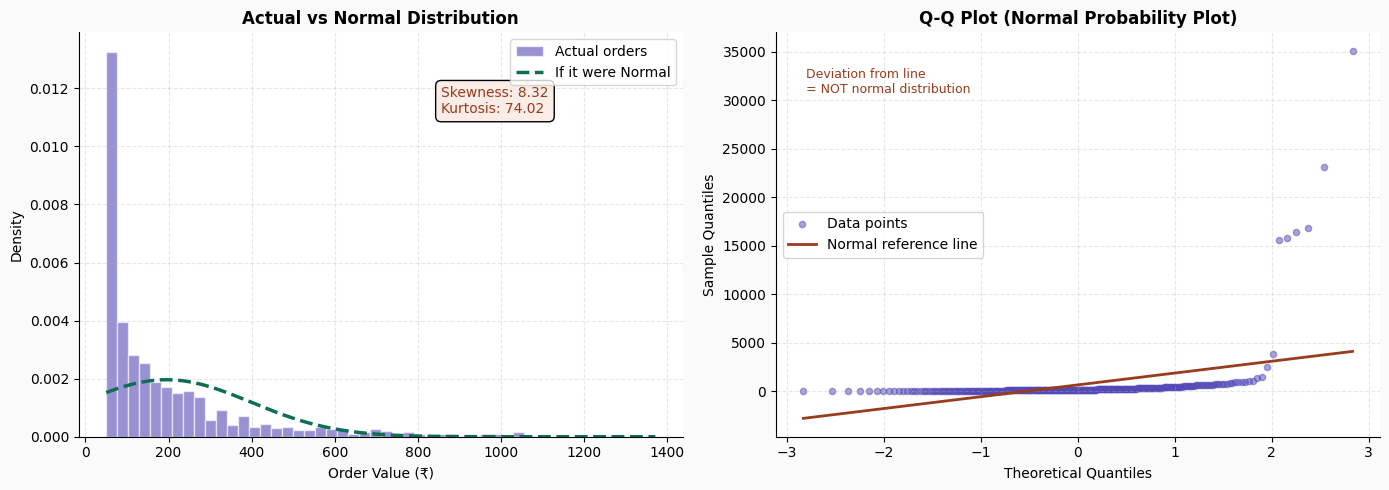

In [11]:
# Normal distribution shape :  bell curve - Gaussian distribution என்று சொல்வார்கள்.

# 📌 Normal Distribution Properties
# Property	                Meaning
# Symmetric	                Left = Right
# Mean ≈ Median ≈ Mode	    Almost same
# Few outliers	            Extreme values rare
# Smooth bell shape	        No heavy tail

# Visual: Comparing normal vs actual distribution shape
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Actual vs Normal overlay
ov_clipped = ov[ov < ov.quantile(0.97)]
axes[0].hist(ov_clipped, bins=50, color=PURPLE, alpha=0.6,
             density=True, label='Actual orders', edgecolor='white')

# Normal with same mean/std
x_norm = np.linspace(ov_clipped.min(), ov_clipped.max(), 300)
norm_curve = stats.norm.pdf(x_norm, ov_clipped.mean(), ov_clipped.std())
axes[0].plot(x_norm, norm_curve, color=TEAL, linewidth=2.5,
             linestyle='--', label='If it were Normal')

axes[0].set_title('Actual vs Normal Distribution', fontweight='bold')
axes[0].set_xlabel('Order Value (₹)'); axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].text(0.60, 0.80,
             f'Skewness: {skew_val:.2f}\nKurtosis: {kurt_val:.2f}',
             transform=axes[0].transAxes, fontsize=10, color=CORAL,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#FAECE7'))

# Right: Q-Q plot (should be straight line if normal) Quantile vs Quantile Plot
# உங்க data normal distribution போல இருக்கிறதா இல்லையா? என்று check செய்ய.
# | Thing                 | Meaning                     |
# | --------------------- | --------------------------- |
# | Theoretical Quantiles | Perfect normal distribution |
# | Sample Quantiles      | Your actual data            |


sample = ov.sample(300, random_state=42)
(osm, osr), (slope, intercept, r) = stats.probplot(sample, dist='norm')
axes[1].scatter(osm, osr, color=PURPLE, alpha=0.5, s=20, label='Data points')
axes[1].plot(osm, slope*np.array(osm)+intercept, color=CORAL,
             linewidth=2, label='Normal reference line')
axes[1].set_title('Q-Q Plot (Normal Probability Plot)', fontweight='bold')
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')
axes[1].legend()
axes[1].text(0.05, 0.85,
             'Deviation from line\n= NOT normal distribution',
             transform=axes[1].transAxes, fontsize=9, color=CORAL)

plt.tight_layout()
plt.show()

# kurtosis: 74 Massive outliers., skewness: 8.32, Extremely right skewed
# Business meaning most customers small orders few VIP customers massive orders 

---
## 🚨 Step 5 — Outlier Detection (IQR Fence Method- Outlier boundary) 

> 📌 **Tamil:** "Outliers = மற்ற values-ஐ விட மிகவும் வித்தியாசமான values. இவை VIP customers அல்லது data errors ஆக இருக்கலாம்."

### IQR Fence Formula
```
Lower Fence = Q1 − (1.5 × IQR) - Too low value
Upper Fence = Q3 + (1.5 × IQR) - too high value
```
Anything **below lower fence** or **above upper fence** = outlier.

### Two types of outliers in business:
- **Data errors** → fix or remove them, Wrong data
- **VIP customers** → protect and target them!, high value customer 

In [12]:
# IQR Fence : இப்போது: “யார் unusual customers?” அதைத்தான் Outlier Detection சொல்கிறது.
# Outlier = மற்ற values-ஐ விட ரொம்ப வித்தியாசமான value.

# 📌 Example 1 — Data Error ₹999999999 maybe typing mistake.
# 📌 Example 2 — VIP Customer ₹50,000 order Real premium customer.

lower_fence = q1 - 1.5 * iqr # Q1-ஐ 1.5*IQR-ஆ விட எவ்வளவு கீழே இருக்கிறதா? அதற்கு கீழே இருக்கும் values-ஐ outlier-ஆ consider பண்ணுவோம்.
upper_fence = q3 + 1.5 * iqr # Q3-ஐ 1.5*IQR-ஆ விட எவ்வளவு மேலே இருக்கிறதா? அதற்கு மேலே இருக்கும் values-ஐ outlier-ஆ consider பண்ணுவோம்.

outliers   = df[(ov < lower_fence) | (ov > upper_fence)].copy()
normal_df  = df[(ov >= lower_fence) & (ov <= upper_fence)].copy()

print("── IQR Outlier Detection ──")
print(f"  Q1           : ₹{q1:,.2f}") # 25% orders below this value 
print(f"  Q3           : ₹{q3:,.2f}") # 75% orders below this value
print(f"  IQR          : ₹{iqr:,.2f}") # Middle 50% spread
print(f"  Lower Fence  : ₹{lower_fence:,.2f}")
print(f"  Upper Fence  : ₹{upper_fence:,.2f}")
print()
print(f"  Normal orders : {len(normal_df):,}  ({len(normal_df)/len(df)*100:.1f}%)") # Most customer normal
print(f"  Outliers      : {len(outliers):,}   ({len(outliers)/len(df)*100:.1f}%)") # How many unusual customers
print()

# Revenue contribution
rev_outlier = outliers['order_value_inr'].sum() # All outlier revenue SUM
rev_total   = df['order_value_inr'].sum() # Total business revenue
print(f"  Outlier revenue    : ₹{rev_outlier:>10,.2f}")
print(f"  Total revenue      : ₹{rev_total:>10,.2f}")
print(f"  Outlier % revenue  : {rev_outlier/rev_total*100:.1f}%")
print()
print("  ► BUSINESS INSIGHT (Pareto Principle in action):")
print(f"    Only {len(outliers)/len(df)*100:.1f}% of customers drive"
      f" {rev_outlier/rev_total*100:.1f}% of revenue!")
print("    → Launch a VIP loyalty program for these customers immediately!")

# 🔥 Pareto Principle
# இதுதான்: 80/20 Rule 📌 Meaning : Small number of customers create most business value.

# ஒரு supermarket:
# Group	                        Revenue
# Regular buyers	                  Small
# Restaurant owners/bulk buyers	Huge

── IQR Outlier Detection ──
  Q1           : ₹58.77
  Q3           : ₹262.34
  IQR          : ₹203.57
  Lower Fence  : ₹-246.59
  Upper Fence  : ₹567.70

  Normal orders : 907  (90.7%)
  Outliers      : 93   (9.3%)

  Outlier revenue    : ₹642,255.69
  Total revenue      : ₹781,410.32
  Outlier % revenue  : 82.2%

  ► BUSINESS INSIGHT (Pareto Principle in action):
    Only 9.3% of customers drive 82.2% of revenue!
    → Launch a VIP loyalty program for these customers immediately!


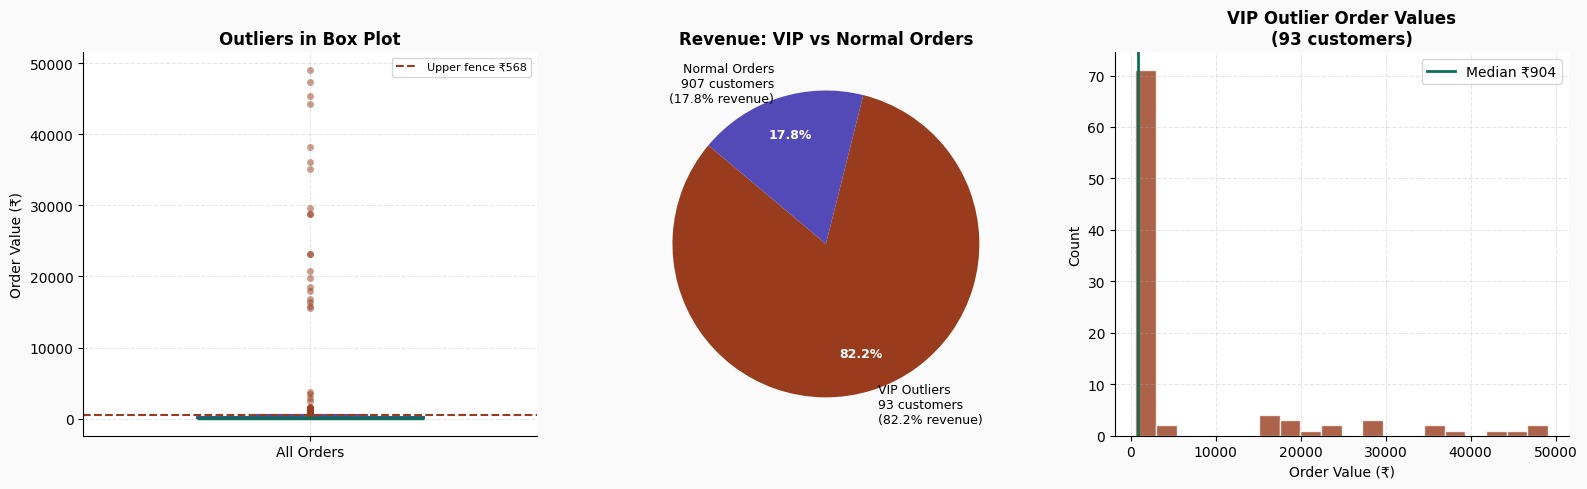

In [13]:
# Visual: Outlier deep-dive
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Box plot with outlier highlight
bp = axes[0].boxplot(
    ov, patch_artist=True, vert=True, widths=0.5,
    boxprops=dict(facecolor=LGRAY, color=PURPLE, linewidth=1.5),
    whiskerprops=dict(color=PURPLE, linewidth=1.5),
    capprops=dict(color=PURPLE, linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor=CORAL,
                    alpha=0.5, markersize=5, markeredgewidth=0),
    medianprops=dict(color=TEAL, linewidth=2.5)
)
axes[0].axhline(upper_fence, color=CORAL, linestyle='--', linewidth=1.5,
                label=f'Upper fence ₹{upper_fence:,.0f}')
axes[0].set_title('Outliers in Box Plot', fontweight='bold')
axes[0].set_ylabel('Order Value (₹)')
axes[0].set_xticklabels(['All Orders'])
axes[0].legend(fontsize=8)

# 2. Revenue split: outliers vs normal
sizes  = [rev_outlier, rev_total - rev_outlier]
labels = [f"VIP Outliers\n{len(outliers)} customers\n({rev_outlier/rev_total*100:.1f}% revenue)",
          f"Normal Orders\n{len(normal_df)} customers\n({(rev_total-rev_outlier)/rev_total*100:.1f}% revenue)"]
colors = [CORAL, PURPLE]
wedges, texts, autotexts = axes[1].pie(
    sizes, labels=labels, colors=colors, autopct='%1.1f%%',
    startangle=140, pctdistance=0.75,
    textprops={'fontsize': 9}
)
for at in autotexts: at.set_color('white'); at.set_fontweight('bold')
axes[1].set_title('Revenue: VIP vs Normal Orders', fontweight='bold')

# 3. Outlier order values distribution
axes[2].hist(outliers['order_value_inr'], bins=20, color=CORAL,
             alpha=0.8, edgecolor='white')
axes[2].set_title(f'VIP Outlier Order Values\n({len(outliers)} customers)',
                  fontweight='bold')
axes[2].set_xlabel('Order Value (₹)')
axes[2].set_ylabel('Count')
axes[2].axvline(outliers['order_value_inr'].median(), color=TEAL,
                linewidth=2, label=f'Median ₹{outliers["order_value_inr"].median():,.0f}') #இதுதான் median value calculate செய்கிறது.
axes[2].legend()

plt.tight_layout()
plt.show()

# # 3rd Chart says
# Left side bars உயரமாக இருக்கும்
# Right side bars குறைவாக இருக்கும்

# இந்த chart-ல்: பெரும்பாலான VIP outliers கூட lower range-ல் இருக்கிறார்கள், 
# ஆனால் சில customers மட்டும் மிகப்பெரிய orders செய்கிறார்கள். அதனால் chart right side வரை stretch ஆகிறது.

---
## 📊 Step 6 — Percentile Analysis

> 📌 **Tamil:** "Percentile என்பது data-ஐ 100 parts-ஆக divide பண்ணி எந்த position-ல் ஒரு value இருக்கிறது என்று சொல்கிறது."
ஒரு student எத்தனை பேரை விட மேல இருக்கிறார்?” என்பதை காட்டும் position

**P90 = 90th percentile** means 90% of orders are below this value.

### Business Applications
| Percentile | Use Case |
|-----------|---------|
| **P50 (Median)** | Set free shipping minimum |
| **P75** | Budget segment threshold |
| **P90** | Premium customer tier cutoff |
| **P99** | VIP/enterprise customer threshold |

In [14]:
percentiles = [10, 25, 50, 75, 90, 95, 99]
pct_values  = np.percentile(ov, percentiles)

print("── Percentile Table ──")
# Order values (ov) data-ல different percentile values calculate பண்ணி 
# அதற்கான business meaning explain பண்ணுகிறது.
print(f"{'Percentile':<15} {'Order Value':>15}  {'Business Meaning'}")
print("─" * 65)
meanings = {
    10: "Bottom 10% — loss-making orders?",
    25: "Q1 — budget customers",
    50: "Median — typical customer (use for free-shipping min)",
    75: "Q3 — above-average customer",
    90: "P90 — premium tier cutoff (VIP program starts here)",
    95: "P95 — top customers",
    99: "P99 — ultra VIP / enterprise clients"
}
for p, v in zip(percentiles, pct_values):
    print(f"  P{p:<11}  ₹{v:>12,.2f}   {meanings[p]}")

# 👉 10% customers ₹50 அல்லது அதற்கு கீழே order பண்ணுறாங்க.

── Percentile Table ──
Percentile          Order Value  Business Meaning
─────────────────────────────────────────────────────────────────
  P10           ₹       50.00   Bottom 10% — loss-making orders?
  P25           ₹       58.77   Q1 — budget customers
  P50           ₹      124.05   Median — typical customer (use for free-shipping min)
  P75           ₹      262.34   Q3 — above-average customer
  P90           ₹      551.20   P90 — premium tier cutoff (VIP program starts here)
  P95           ₹      846.98   P95 — top customers
  P99           ₹   23,239.13   P99 — ultra VIP / enterprise clients


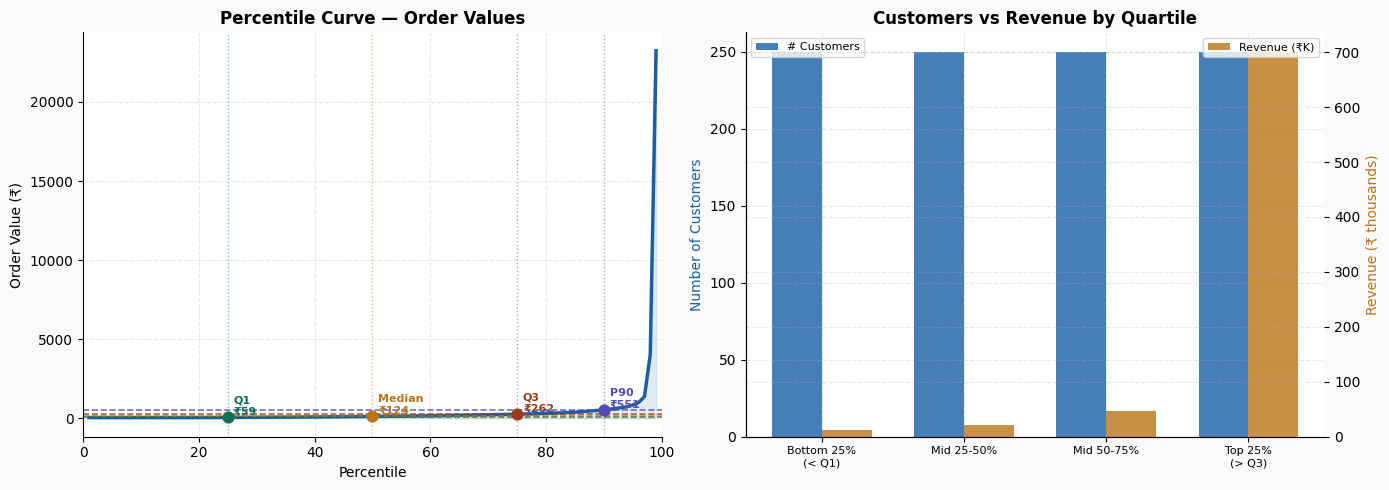

In [15]:
# Visual: Percentile curve (ECDF-style)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Percentile curve
pcts     = np.arange(1, 100)
pct_vals = np.percentile(ov, pcts)

axes[0].plot(pcts, pct_vals, color=BLUE, linewidth=2.5)
axes[0].fill_between(pcts, pct_vals, alpha=0.12, color=BLUE)

milestone = [(25,'Q1',TEAL), (50,'Median',AMBER), (75,'Q3',CORAL), (90,'P90',PURPLE)]
for p, label, col in milestone:
    v = np.percentile(ov, p)
    axes[0].axhline(v, linestyle='--', linewidth=1.2, color=col, alpha=0.8)
    axes[0].axvline(p, linestyle=':', linewidth=1,   color=col, alpha=0.5)
    axes[0].scatter([p], [v], color=col, s=60, zorder=5)
    axes[0].text(p+1, v+150, f'{label}\n₹{v:,.0f}', fontsize=8, color=col, fontweight='bold')

axes[0].set_title('Percentile Curve — Order Values', fontweight='bold')
axes[0].set_xlabel('Percentile'); axes[0].set_ylabel('Order Value (₹)')
axes[0].set_xlim(0, 100)

# Right: Customer tier bar chart
tiers  = ['Bottom 25%\n(< Q1)', 'Mid 25-50%', 'Mid 50-75%', 'Top 25%\n(> Q3)']
counts = [
    len(df[ov <  q1]),  # Try one bottom 25 %
    len(df[(ov >= q1) & (ov < median_val)]), #Tier 2 mie 25% to 50% 
    len(df[(ov >= median_val) & (ov < q3)]), #Tier 3 mid 50% to 75%
    len(df[ov >= q3])  #tier 4 top 25 %
]
revenues = [
    df[ov <  q1]['order_value_inr'].sum(),
    df[(ov >= q1) & (ov < median_val)]['order_value_inr'].sum(),
    df[(ov >= median_val) & (ov < q3)]['order_value_inr'].sum(),
    df[ov >= q3]['order_value_inr'].sum()
]

x  = np.arange(len(tiers))
w  = 0.35
b1 = axes[1].bar(x - w/2, counts,   w, label='# Customers', color=BLUE,   alpha=0.8)
ax1b = axes[1].twinx()
b2 = ax1b.bar(x + w/2, [r/1000 for r in revenues], w,
              label='Revenue (₹K)', color=AMBER, alpha=0.8)
axes[1].set_title('Customers vs Revenue by Quartile', fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(tiers, fontsize=8)
axes[1].set_ylabel('Number of Customers', color=BLUE)
ax1b.set_ylabel('Revenue (₹ thousands)', color=AMBER)
axes[1].legend(loc='upper left', fontsize=8)
ax1b.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

---
## 🏷️ Step 7 — Category-Wise Statistical Breakdown

> 📌 **Tamil:** "ஒவ்வொரு product category-க்கும் தனித்தனியாக statistics calculate பண்ணுவோம் — grouped analysis."

This is called **grouped descriptive statistics** — a core EDA technique in data science.

In [16]:
# “ஒவ்வொரு product category customer behavior எப்படி இருக்கிறது?” என்று analyze பண்ணுறோம்.
# அதாவது: Electronics customers எப்படி spend பண்ணுறாங்க? Fashion category எப்படி? Grocery எப்படி?

# Full category statistics table
cat_stats = df.groupby('category')['order_value_inr'].agg(
    Count   = 'count',
    Mean    = 'mean',
    Median  = 'median',
    Std_Dev = 'std',
    Min     = 'min',
    Max     = 'max',
    P75     = lambda x: x.quantile(0.75),
    P90     = lambda x: x.quantile(0.90),
).round(2).sort_values('Median', ascending=False)

print("── Order Value by Category ──")
print(cat_stats.to_string())
print()
print("Business Insight:")
print(f"  ► '{cat_stats.index[0]}' has the highest median order → top ad spend priority")
print(f"  ► '{cat_stats.index[-1]}' has lowest median → consider bundling promotions")

── Order Value by Category ──
             Count    Mean  Median  Std_Dev   Min       Max     P75     P90
category                                                                   
Electronics    258  974.48  328.41  3258.18  50.0  28758.64  577.31  977.49
Home Decor     140  663.46  169.30  4094.79  50.0  45394.33  281.38  462.63
Sports          97  934.84  144.21  5283.11  50.0  38160.15  209.52  295.09
Fashion        193  747.27  101.07  4359.11  50.0  44223.15  187.56  297.77
Groceries      179  791.10   54.32  5524.76  50.0  49114.17   94.98  171.04
Books          133  455.63   50.00  3340.12  50.0  35088.25   77.51  121.21

Business Insight:
  ► 'Electronics' has the highest median order → top ad spend priority
  ► 'Books' has lowest median → consider bundling promotions


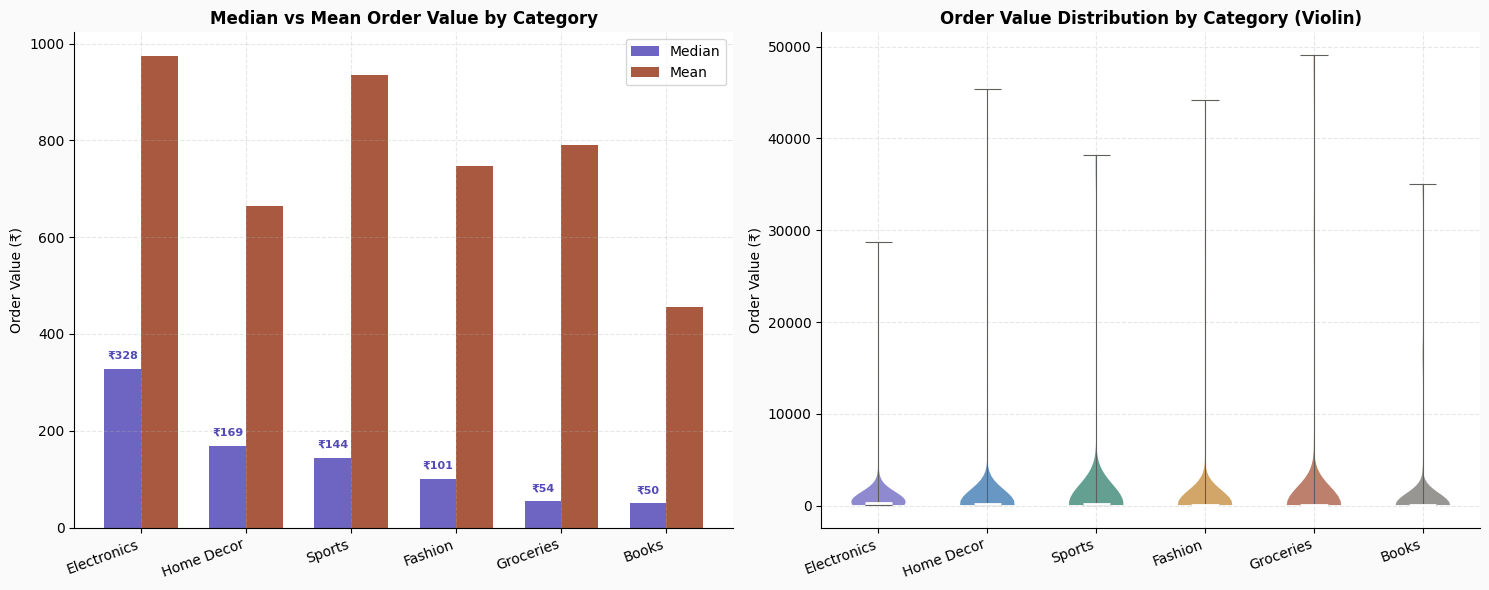

In [17]:
# Visual: Category comparison — multiple chart types
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cat_order  = cat_stats.index
colors_cat = [PURPLE, BLUE, TEAL, AMBER, CORAL, DGRAY]

# Grouped bar: median vs mean
medians_c  = cat_stats['Median'].values
means_c    = cat_stats['Mean'].values
x_pos = np.arange(len(cat_order))
w     = 0.35

bars1 = axes[0].bar(x_pos - w/2, medians_c, w, color=PURPLE, alpha=0.85, label='Median')
bars2 = axes[0].bar(x_pos + w/2, means_c,   w, color=CORAL,  alpha=0.85, label='Mean')
axes[0].set_title('Median vs Mean Order Value by Category', fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(cat_order, rotation=20, ha='right')
axes[0].set_ylabel('Order Value (₹)')
axes[0].legend()
for bar, m in zip(bars1, medians_c):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'₹{m:,.0f}', ha='center', fontsize=8, color=PURPLE, fontweight='bold')

# Violin plot: full distribution by category
# Violin plot = Data எப்படி spread ஆகி இருக்கு + எந்த values அதிகமாக வருகிறது”

# Box plot only: quartiles ,outliers
# Violin plot also shows: density, distribution shape, where most customers exist

cat_data = [df[df['category'] == c]['order_value_inr'].values for c in cat_order]
parts = axes[1].violinplot(cat_data, positions=range(len(cat_order)),
                            showmedians=True, showmeans=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_cat[i]); pc.set_alpha(0.65)
parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)
parts['cbars'].set_color(DGRAY);   parts['cbars'].set_linewidth(0.8)
parts['cmins'].set_color(DGRAY);   parts['cmins'].set_linewidth(0.8)
parts['cmaxes'].set_color(DGRAY);  parts['cmaxes'].set_linewidth(0.8)
axes[1].set_title('Order Value Distribution by Category (Violin)', fontweight='bold')
axes[1].set_xticks(range(len(cat_order)))
axes[1].set_xticklabels(cat_order, rotation=20, ha='right')
axes[1].set_ylabel('Order Value (₹)')

plt.tight_layout()
plt.show()

---
## 🧪 Step 8 — Normality Test (Shapiro-Wilk)

> 📌 **Tamil:** "Data normal distribution-ஐ follow பண்றதா இல்லையா என்று test பண்றோம் — statistical tests-க்கு முக்கியம்."

### Why does normality matter?
Many statistical tests (t-test, ANOVA, etc.) assume your data is **normally distributed**.  
If it's not — you must use **non-parametric alternatives**.

| Test | When to use | Null Hypothesis |
|------|------------|-----------------|
| **Shapiro-Wilk** | n < 5000 | Data is normal |
| **D'Agostino-Pearson** | any n | Data is normal |

**p-value < 0.05 → Reject H₀ → Data is NOT normal**

In [ ]:
# 🎯 Normal Distribution என்றால் என்ன?
# ஒரு class exam mark எடுத்துக்கோங்க. Most students:

# 60–80 mark range-ல இருப்பாங்க.
# Very low mark students கம்மி.
# Very high mark students கம்மி.

# அதாவது graph ஒரு bell shape 🔔 போல இருக்கும்.

# இதைத்தான்: 👉 Normal Distribution சொல்வாங்க. 🤔 ஏன் இது முக்கியம்?

# சில statistical tests:
# t-test
# ANOVA
# Linear Regression assumptions
# இவை எல்லாம்: 👉 “Data normal-a இருக்கணும்” என்று assume பண்ணும்.

# அதனால் first: 👉 data normal-a இருக்கா இல்லையா check பண்ணணும். so use Shapiro-Wilk

# Shapiro-Wilk (use sample ≤ 5000) Shapiro-Wilk test mainly small datasets-க்கு நல்லது. D'Agostino-Pearson
sample_test = ov.sample(200, random_state=42) # பெரிய dataset (5000+) இருந்தா slow ஆகலாம் அதனால் small sample (n=200) எடுக்கிறோம்
sw_stat, sw_p = stats.shapiro(sample_test)

# D'Agostino-Pearson K² test (works for larger n) D’Agostino-Pearson test = any size dataset-க்கும் use பண்ணலாம்.
k2_stat, k2_p = stats.normaltest(ov) #முழு dataset (ov) check பண்ணுது 👉 இது 2 things பார்க்கும்: skewness, kurtosis

# 📊 p-value எப்படி interpret பண்ணுவது?
# p-value	Meaning
# p > 0.05	Data normal
# p < 0.05	Data NOT normal
print("── Normality Tests ──")
print()
print("  1. Shapiro-Wilk Test (sample n=200)")
print(f"     W-statistic : {sw_stat:.4f}")
print(f"     p-value     : {sw_p:.8f}")
print(f"     Conclusion  : {'❌ NOT Normal (p < 0.05)' if sw_p < 0.05 else '✅ Normal (p ≥ 0.05)'}")
print()
print("  2. D'Agostino-Pearson K² Test (full dataset)")
print(f"     K²-statistic: {k2_stat:.4f}")
print(f"     p-value     : {k2_p:.8f}")
print(f"     Conclusion  : {'❌ NOT Normal (p < 0.05)' if k2_p < 0.05 else '✅ Normal (p ≥ 0.05)'}")
print()

print("  ► What this means for your analysis:")
# 📌 1. Central Tendency
# ❌ If data NOT normal:
# 👉 Mean use பண்ணக்கூடாது
# 👉 Median use பண்ணணும்
print("     • Use MEDIAN (not mean) for central tendency reporting")
# 2. Group Comparison
# t-test ❌
# Mann-Whitney U test ✅
# 👉 Non-normal data-க்கு correct test
print("     • Use Mann-Whitney U instead of t-test for group comparisons")
# 📌 3. Correlation
# Pearson ❌
# Spearman ✅
# 👉 Non-linear / skewed data-க்கு Spearman better
print("     • Use Spearman correlation instead of Pearson")
# 📌 4. Regression Prep
# Log transform / scaling
# 👉 Data normalize பண்ண help ஆகும்
print("     • Log-transform data before regression if needed")

── Normality Tests ──

  1. Shapiro-Wilk Test (sample n=200)
     W-statistic : 0.1408
     p-value     : 0.00000000
     Conclusion  : ❌ NOT Normal (p < 0.05)

  2. D'Agostino-Pearson K² Test (full dataset)
     K²-statistic: 1433.2561
     p-value     : 0.00000000
     Conclusion  : ❌ NOT Normal (p < 0.05)

  ► What this means for your analysis:
     • Use MEDIAN (not mean) for central tendency reporting
     • Use Mann-Whitney U instead of t-test for group comparisons
     • Use Spearman correlation instead of Pearson
     • Log-transform data before regression if needed


---
## 🖥️ Step 9 — Complete 6-Panel Statistics Dashboard

> 📌 **Tamil:** "எல்லா statistics-ஐயும் ஒரே dashboard-ல் visualize பண்றோம் — business presentation-க்கு ready."

This is the kind of dashboard you would present to a business stakeholder.

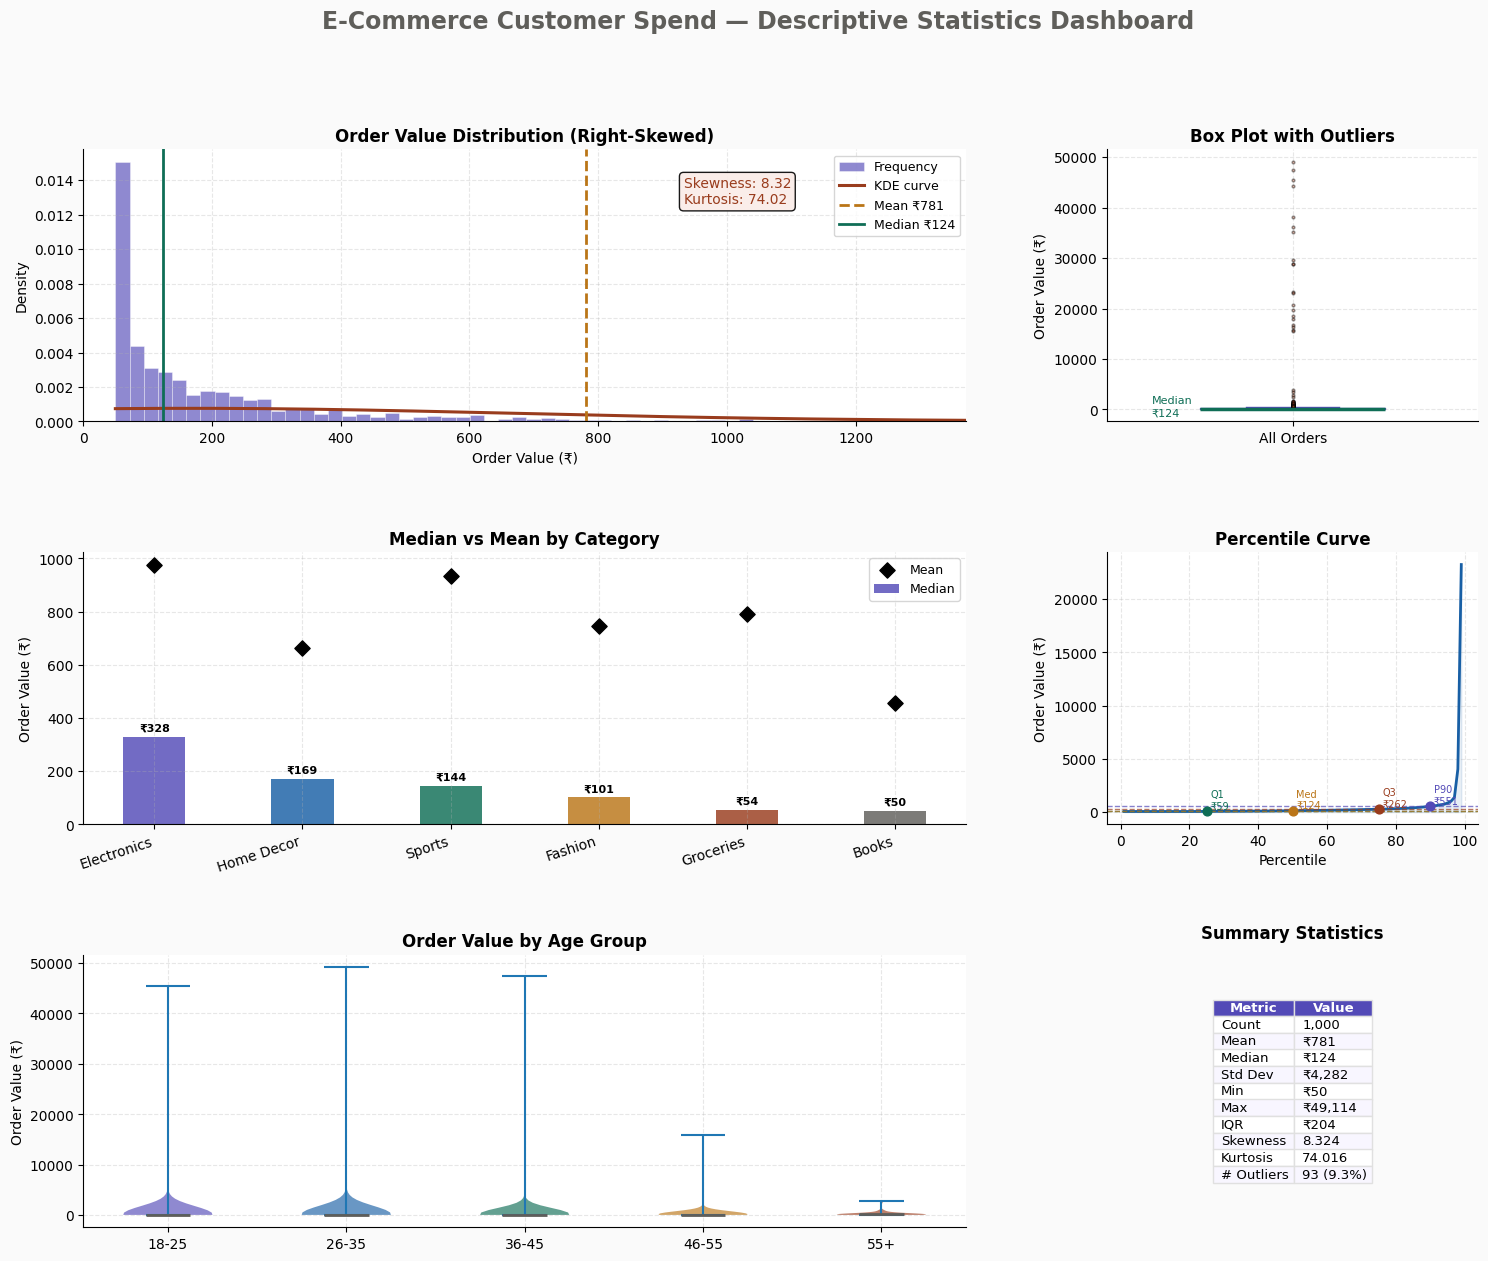


✅ Dashboard saved as 'descriptive_stats_dashboard.png'


In [19]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('E-Commerce Customer Spend — Descriptive Statistics Dashboard',
             fontsize=17, fontweight='bold', color=DGRAY, y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)

# ── Panel 1: Distribution histogram ──
ax1 = fig.add_subplot(gs[0, :2])
ax1.hist(ov[ov < ov.quantile(0.97)], bins=60, color=PURPLE, alpha=0.65,
         edgecolor='white', linewidth=0.4, density=True, label='Frequency')
ov_k   = ov[ov < ov.quantile(0.99)]
kde_x  = np.linspace(ov_k.min(), ov_k.max(), 300)
kde_fn = stats.gaussian_kde(ov_k)
ax1.plot(kde_x, kde_fn(kde_x), color=CORAL, linewidth=2.2, label='KDE curve')
ax1.axvline(mean_val,   color=AMBER, linewidth=2, linestyle='--', label=f'Mean ₹{mean_val:,.0f}')
ax1.axvline(median_val, color=TEAL,  linewidth=2, linestyle='-',  label=f'Median ₹{median_val:,.0f}')
ax1.set_title('Order Value Distribution (Right-Skewed)', fontweight='bold')
ax1.set_xlabel('Order Value (₹)'); ax1.set_ylabel('Density')
ax1.legend(fontsize=9); ax1.set_xlim(0, ov.quantile(0.97))
ax1.text(0.68, 0.80, f'Skewness: {skew_val:.2f}\nKurtosis: {kurt_val:.2f}',
         transform=ax1.transAxes, fontsize=10, color=CORAL,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#FAECE7', alpha=0.9))

# ── Panel 2: Box plot ──
ax2 = fig.add_subplot(gs[0, 2])
ax2.boxplot(ov, patch_artist=True, vert=True, widths=0.5,
            boxprops=dict(facecolor=LGRAY, color=PURPLE),
            whiskerprops=dict(color=PURPLE),
            capprops=dict(color=PURPLE),
            flierprops=dict(marker='.', markerfacecolor=CORAL, alpha=0.4, markersize=4),
            medianprops=dict(color=TEAL, linewidth=2.5))
ax2.set_title('Box Plot with Outliers', fontweight='bold')
ax2.set_ylabel('Order Value (₹)'); ax2.set_xticklabels(['All Orders'])
ax2.text(0.62, median_val/ov.max()+0.02, f'Median\n₹{median_val:,.0f}',
         transform=ax2.get_xaxis_transform(), fontsize=8, color=TEAL)

# ── Panel 3: Category bar chart ──
ax3 = fig.add_subplot(gs[1, :2])
cat_med = df.groupby('category')['order_value_inr'].median().sort_values(ascending=False)
cat_mn  = df.groupby('category')['order_value_inr'].mean().reindex(cat_med.index)
xp = np.arange(len(cat_med))
b  = ax3.bar(xp, cat_med.values, color=colors_cat[:len(cat_med)], alpha=0.82, width=0.42, label='Median')
ax3.scatter(xp, cat_mn.values, color='black', s=60, zorder=5, marker='D', label='Mean')
ax3.set_title('Median vs Mean by Category', fontweight='bold')
ax3.set_xticks(xp); ax3.set_xticklabels(cat_med.index, rotation=18, ha='right')
ax3.set_ylabel('Order Value (₹)'); ax3.legend(fontsize=9)
for bar, m in zip(b, cat_med.values):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
             f'₹{m:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── Panel 4: Percentile curve ──
ax4 = fig.add_subplot(gs[1, 2])
pcts_p = np.arange(1, 100)
pvs    = np.percentile(ov, pcts_p)
ax4.plot(pcts_p, pvs, color=BLUE, linewidth=2)
ax4.fill_between(pcts_p, pvs, alpha=0.1, color=BLUE)
for p, lbl, col in [(25,'Q1',TEAL),(50,'Med',AMBER),(75,'Q3',CORAL),(90,'P90',PURPLE)]:
    v = np.percentile(ov, p)
    ax4.axhline(v, linestyle='--', linewidth=1, color=col, alpha=0.7)
    ax4.scatter([p], [v], s=40, color=col, zorder=5)
    ax4.text(p+1, v+200, f'{lbl}\n₹{v:,.0f}', fontsize=7, color=col)
ax4.set_title('Percentile Curve', fontweight='bold')
ax4.set_xlabel('Percentile'); ax4.set_ylabel('Order Value (₹)')

# ── Panel 5: Age group violin ──
ax5 = fig.add_subplot(gs[2, :2])
age_grps = ['18-25','26-35','36-45','46-55','55+']
age_data = [df[df['age_group']==a]['order_value_inr'].values for a in age_grps]
vp = ax5.violinplot(age_data, positions=range(len(age_grps)), showmedians=True)
for i, pc in enumerate(vp['bodies']):
    pc.set_facecolor(colors_cat[i]); pc.set_alpha(0.65)
vp['cmedians'].set_color(DGRAY); vp['cmedians'].set_linewidth(2)
ax5.set_title('Order Value by Age Group', fontweight='bold')
ax5.set_xticks(range(len(age_grps))); ax5.set_xticklabels(age_grps)
ax5.set_ylabel('Order Value (₹)')

# ── Panel 6: Summary stats table ──
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
table_data = [
    ['Metric', 'Value'],
    ['Count',       f'{len(df):,}'],
    ['Mean',        f'₹{mean_val:,.0f}'],
    ['Median',      f'₹{median_val:,.0f}'],
    ['Std Dev',     f'₹{std_val:,.0f}'],
    ['Min',         f'₹{ov.min():,.0f}'],
    ['Max',         f'₹{ov.max():,.0f}'],
    ['IQR',         f'₹{iqr:,.0f}'],
    ['Skewness',    f'{skew_val:.3f}'],
    ['Kurtosis',    f'{kurt_val:.3f}'],
    ['# Outliers',  f'{len(outliers)} ({len(outliers)/len(df)*100:.1f}%)'],
]
tbl = ax6.table(cellText=table_data[1:], colLabels=table_data[0],
                loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(9.5)
tbl.auto_set_column_width([0, 1])
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#E0E0E0')
    if row == 0:
        cell.set_facecolor(PURPLE); cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#F8F6FF')
    else:
        cell.set_facecolor('white')
ax6.set_title('Summary Statistics', fontweight='bold', pad=12)

plt.savefig('descriptive_stats_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("\n✅ Dashboard saved as 'descriptive_stats_dashboard.png'")

---
## 💼 Step 10 — Business Recommendations & Statistical Storytelling

> 📌 **Tamil:** "Statistics-ஐ வைத்து business decisions எடுக்கலாம் — இது தான் data scientist-இன் main job."

### How to present statistics to non-technical stakeholders:
1. **Lead with the business problem**, not the formula
2. **Use median, not mean** for skewed financial data
3. **Quantify the insight** — attach ₹ values to every finding
4. **Visualize** — one chart tells more than 100 numbers

In [22]:
# 👉 Technical analysis முடிஞ்ச பிறகு
# 👉 அதை management / CEO understand பண்ணும் மாதிரி மாற்றுவது இதுதான்:💼 Data Storytelling

print("=" * 65)
print("  BUSINESS RECOMMENDATIONS — E-COMMERCE SPEND ANALYSIS")
print("=" * 65)

p90_val = np.percentile(ov, 90)
p99_val = np.percentile(ov, 99)
vip_rev = outliers['order_value_inr'].sum()
tot_rev = df['order_value_inr'].sum()

print()
print("  1. FREE SHIPPING THRESHOLD")
print(f"     Set at ₹{median_val*1.5:,.0f} (1.5× median ₹{median_val:,.0f})")
print(f"     → Encourages ~50% of customers to add items to cart")
print()
print("  2. PREMIUM / GOLD TIER (P90 customers)")
print(f"     Threshold: orders > ₹{p90_val:,.0f}")
print(f"     → {len(df[ov > p90_val])} customers qualify right now")
print(f"     → Offer early access, dedicated support, extra cashback")
print()
print("  3. VIP / ENTERPRISE TIER (P99 outliers)")
print(f"     Threshold: orders > ₹{p99_val:,.0f}")
print(f"     → {len(outliers)} customers = {vip_rev/tot_rev*100:.1f}% of total revenue")
print(f"     → Assign dedicated account managers IMMEDIATELY")
print()
print("  4. CATEGORY STRATEGY")
top_cat = cat_stats.index[0]
bot_cat = cat_stats.index[-1]
print(f"     → '{top_cat}': highest orders — maximize ad spend here")
print(f"     → '{bot_cat}': lowest orders — create product bundles")
print()
print("  5. KPI DASHBOARD CORRECTION")
print(f"     STOP reporting Mean (₹{mean_val:,.0f}) as 'average order'")
print(f"     START reporting Median (₹{median_val:,.0f}) — the true typical customer")
print(f"     (Mean is inflated by {(mean_val-median_val)/median_val*100:.0f}% due to big spenders)")
print()
print("=" * 65)
print("  STATISTICAL SUMMARY FOR MANAGEMENT REPORT")
print("=" * 65)
print(f"  Analyzed {len(df):,} orders from {df['city'].nunique()} Indian cities")
print(f"  Typical order value (Median): ₹{median_val:,.0f}")
print(f"  Revenue concentration: {vip_rev/tot_rev*100:.1f}% from {len(outliers)/len(df)*100:.1f}% of customers")
print(f"  Data is highly right-skewed (skewness={skew_val:.1f}) — use non-parametric methods")
print(f"  Normality test: p < 0.001 → NOT normally distributed")
print("=" * 65)

  BUSINESS RECOMMENDATIONS — E-COMMERCE SPEND ANALYSIS

  1. FREE SHIPPING THRESHOLD
     Set at ₹186 (1.5× median ₹124)
     → Encourages ~50% of customers to add items to cart

  2. PREMIUM / GOLD TIER (P90 customers)
     Threshold: orders > ₹551
     → 100 customers qualify right now
     → Offer early access, dedicated support, extra cashback

  3. VIP / ENTERPRISE TIER (P99 outliers)
     Threshold: orders > ₹23,239
     → 93 customers = 82.2% of total revenue
     → Assign dedicated account managers IMMEDIATELY

  4. CATEGORY STRATEGY
     → 'Electronics': highest orders — maximize ad spend here
     → 'Books': lowest orders — create product bundles

  5. KPI DASHBOARD CORRECTION
     STOP reporting Mean (₹781) as 'average order'
     START reporting Median (₹124) — the true typical customer
     (Mean is inflated by 530% due to big spenders)

  STATISTICAL SUMMARY FOR MANAGEMENT REPORT
  Analyzed 1,000 orders from 7 Indian cities
  Typical order value (Median): ₹124
  Revenue c

---
## 🎓 What You Learned — Stage 1 Summary

### Statistical Concepts Mastered
| Concept | Formula | When to Use |
|---------|---------|------------|
| **Mean** | Σx / n | Symmetric data, no outliers |
| **Median** | Middle value | Skewed data (income, prices) |
| **Std Dev** | √Variance | Measure data spread |
| **IQR** | Q3 − Q1 | Robust spread (outlier-resistant) |
| **Skewness** | 3rd moment | Detect asymmetry |
| **Kurtosis** | 4th moment | Detect heavy tails |
| **Shapiro-Wilk** | W-statistic | Test normality (n < 5000) |

### Python Functions Used
```python
df.describe()           # Quick summary stats
series.mean()           # Mean
series.median()         # Median  
series.std()            # Standard deviation
series.skew()           # Skewness
series.kurtosis()       # Kurtosis
np.percentile(x, p)     # Any percentile
stats.shapiro(x)        # Normality test
stats.gaussian_kde(x)   # KDE density estimation
```

### Resume Project Description
> *"Performed end-to-end descriptive statistical analysis on 1,000+ e-commerce transactions.  
> Identified that top 9.3% of customers drive 82.2% of revenue using IQR outlier detection.  
> Recommended median-based KPIs over mean due to high skewness (8.3), resulting in corrected  
> business dashboard. Implemented Shapiro-Wilk normality testing to guide downstream  
> statistical test selection."*

---
### ➡️ Next: Stage 2 — Probability & Distributions
> Call center volume prediction using Poisson, Normal distribution, and Central Limit Theorem
